<a href="https://colab.research.google.com/github/hali49/AI-Phishing-Detection-Project/blob/main/haiderBali494_hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diffusion model

The primary goal of this assignment is to implement, train, and evaluate a Denoising Diffusion Probabilistic Model (DDPM) from scratch, enabling you to generate realistic images from the CIFAR-10 dataset.

Through this project, you will:

**Understand the diffusion paradigm**: Learn how images can be "diffused" into pure noise via a Markov chain and reversibly "denoised" to reconstruct or generate new samples.

**Implement key building blocks**: Construct a U-Net with time embeddings, residual blocks, and attention; define Gaussian diffusion schedules; and train via simple noise prediction loss.

**Explore variations**: Compare unconditional generation (diverse but unguided) with conditional generation using classifier-free guidance (CFG) for class-specific control.




# Diffusion Model Implementation - Grading Rubric (40 Points)

| Component | Points |
|-----------|--------|
| **ResidualBlock** | 6 |
| **AttentionBlock** | 6 |
| **Downsample** | 2 |
| **Upsample** | 2 |
| **UNet** | 8 |
| **GaussianDiffusion** | 8 |
| **train_unconditional** | 4 |
| **train_conditional** | 4 |
| **Total** | **40** |

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import math
from einops import rearrange, reduce
import os
from torchvision.datasets import CIFAR10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cpu


***Helper functions***

In [ ]:
def plot_training_losses(train_losses, val_losses=None, save_path=None):

    plt.figure(figsize=(12, 5))
    epochs = range(1, len(train_losses) + 1)

    # Plot training loss
    plt.plot(epochs, train_losses, 'b-o', linewidth=2, markersize=4, label='Train Loss')

    # Plot validation loss if provided
    if val_losses is not None:
        plt.plot(epochs, val_losses, 'r-s', linewidth=2, markersize=4, label='Val Loss')

        # Highlight overfitting regions (where val > train significantly)
        for i in range(len(train_losses)):
            if val_losses[i] > train_losses[i] * 1.15:  # 15% threshold
                plt.axvspan(i+0.5, i+1.5, alpha=0.2, color='red')

    plt.xlabel('Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('Loss', fontsize=12, fontweight='bold')

    # Update title based on whether validation is included
    if val_losses is not None:
        plt.title('Training vs Validation Loss', fontsize=14, fontweight='bold')
    else:
        plt.title('Training Loss', fontsize=14, fontweight='bold')

    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')

    plt.show()

def save_checkpoint(model, optimizer, epoch, loss, filepath):
    """Save model checkpoint"""
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, filepath)
    print(f"Checkpoint saved to {filepath}")

def load_checkpoint(model, optimizer, filepath):
    """Load model checkpoint"""
    checkpoint = torch.load(filepath)
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    print(f"Checkpoint loaded from {filepath} (Epoch {epoch}, Loss {loss:.4f})")
    return epoch, loss


def visualize_forward_diffusion(x_0, diffusion, timesteps_to_show=[0, 100, 200, 400, 600, 999],
                               save_path=None):
    """Show how an image gets corrupted by noise over time"""
    fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(20, 4))

    for idx, t in enumerate(timesteps_to_show):
        t_tensor = torch.tensor([t], device=x_0.device)
        noisy_image = diffusion.q_sample(x_0, t_tensor)

        # Denormalize
        img = noisy_image[0].cpu() * 0.5 + 0.5
        img = torch.clamp(img, 0, 1)

        axes[idx].imshow(img.permute(1, 2, 0))
        axes[idx].set_title(f't = {t}')
        axes[idx].axis('off')

    plt.suptitle('Forward Diffusion Process', fontsize=16)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


@torch.no_grad()
def visualize_reverse_diffusion(model, diffusion, shape, timesteps_to_show=[999, 600, 400, 200, 100, 0],
                               save_path=None):
    """Show how noise gradually becomes an image"""
    device = next(model.parameters()).device

    # Start from noise
    img = torch.randn(shape, device=device)

    images = {}

    for t in tqdm(reversed(range(0, diffusion.timesteps)), desc='Reverse diffusion'):
        t_tensor = torch.full((shape[0],), t, device=device, dtype=torch.long)
        img = diffusion.p_sample(model, img, t_tensor)

        if t in timesteps_to_show:
            images[t] = img.clone()

    # Plot
    fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(20, 4))

    for idx, t in enumerate(timesteps_to_show):
        # Denormalize
        img_show = images[t][0].cpu() * 0.5 + 0.5
        img_show = torch.clamp(img_show, 0, 1)

        axes[idx].imshow(img_show.permute(1, 2, 0))
        axes[idx].set_title(f't = {t}')
        axes[idx].axis('off')

    plt.suptitle('Reverse Diffusion Process (Denoising)', fontsize=16)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

import torch
import torchvision
import matplotlib.pyplot as plt

CIFAR10_CLASSES = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

def show_images(images, labels=None, nrow=8, save_path=None):
    """
    images: (B,C,H,W) tensor in [-1,1] or [0,1] (float) or [0,255] (uint8)
    """
    # Ensure shape
    assert images.ndim == 4 and images.shape[1] in (1,3), "Expect (B,C,H,W)"

    # Convert to float [0,1]
    if images.dtype == torch.uint8:
        imgs = images.float() / 255.0
    else:
        imgs = images.clone().float()
        # If looks like [-1,1], denormalize
        if imgs.min() < -0.1:
            imgs = imgs * 0.5 + 0.5

    imgs = imgs.clamp(0, 1)  # stay in displayable range

    # Build grid (set padding to white)
    grid = torchvision.utils.make_grid(
        imgs.cpu(), nrow=nrow, padding=2, pad_value=1.0
    )

    # Show with nearest interpolation to avoid blur
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).cpu(), interpolation='nearest')
    plt.axis('off')

    if labels is not None:
        label_names = [CIFAR10_CLASSES[int(l)] for l in labels[:nrow]]
        plt.title(' | '.join(label_names))

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=200)

    plt.show()



## Part 1: Data Loading and Preparation

In [ ]:
def create_cifar_dataloaders(batch_size,num_workers=4):

    transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Scale to [-1, 1]
])

    train_dataset=CIFAR10(root="./cifar10_data",\
                        train=True,\
                        download=True,\
                        transform=transform
                        )
    test_dataset=CIFAR10(root="./cifar10_data",\
                        train=False,\
                        download=True,\
                        transform=transform
                        )

    return DataLoader(train_dataset,batch_size=batch_size,shuffle=True,num_workers=num_workers),\
            DataLoader(test_dataset,batch_size=batch_size,shuffle=False,num_workers=num_workers)

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
train_dataloader,test_dataloader=create_cifar_dataloaders(batch_size=256)

100%|██████████| 170M/170M [00:02<00:00, 79.9MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


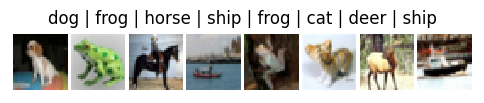

In [ ]:
sample_images, sample_labels = next(iter(train_dataloader))
show_images(sample_images[:8], sample_labels[:8])

## Part 2: Understanding Noise and Corruption

Build intuition for the diffusion process by implementing a simple noise corruption function. Understand how images degrade under noise and why this degradation is reversible with the right model.


In this section, we introduce the **forward diffusion process**: gradually adding Gaussian noise to images over 1000 timesteps until they become pure noise. This creates a learnable "noising" chain that the model will reverse during generation.






In [ ]:
def corrupt(x, amount):
    """Corrupt the input `x` by mixing it with noise according to `amount`"""
    noise = torch.rand_like(x)
    amount = amount.view(-1, 1, 1, 1)
    return x * (1 - amount) + noise * amount

### Key Components
- **`corrupt(x, amount)`**: A naive baseline, linearly mixes image `x` with uniform random noise based on `amount` (0=original, 1=full noise). Useful for contrast, but lacks probabilistic structure.
- **Noise Schedules**:
  - `linear_beta_schedule`: Linearly interpolates β (noise variance) from small (1e-4) to large (0.02), ensuring slow initial corruption.
  - `cosine_beta_schedule`: Smoother cosine-based curve (inspired by improved DDPMs), clipping extremes for numerical stability often yields better samples.
- **`SimpleDiffusion` Class**: Encapsulates the process. Precomputes α=1-β and cumulatives (√ᾱ_t, √(1-ᾱ_t)) for efficient `q_sample(x_start, t)`:  
  **q(x_t | x_0) = √ᾱ_t ⋅ x_0 + √(1-ᾱ_t) ⋅ ε** (ε ~ N(0,1)).  
  The `extract` helper broadcasts schedule values to batch/tensor shapes.
- **`compare_corruption_methods`**: Visualizes evolution over timesteps:  
  - **Row 1 (Green)**: Original image (reference).  
  - **Row 2 (Red)**: Naive linear corruption (destructs too fast).  
  - **Row 3 (Blue)**: DDPM forward (gradual, preserves structure longer).  


In [ ]:
def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    """Linear schedule for beta values"""
    return torch.linspace(beta_start, beta_end, timesteps)


def cosine_beta_schedule(timesteps, s=0.008):
    """Cosine schedule for beta values"""
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)


class SimpleDiffusion:
    """Simple diffusion process for demonstration"""
    def __init__(self, timesteps=1000, beta_schedule='linear'):
        self.timesteps = timesteps


        if beta_schedule == 'linear':
            betas = linear_beta_schedule(timesteps)
        elif beta_schedule == 'cosine':
            betas = cosine_beta_schedule(timesteps)
        else:
            raise ValueError(f"Unknown beta schedule: {beta_schedule}")


        self.betas = betas
        self.alphas = 1.0 - betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

    def extract(self, a, t, x_shape):
        """Extract values from array at indices t"""
        batch_size = t.shape[0]
        out = a.gather(0, t)
        return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))

    def q_sample(self, x_start, t, noise=None):
        """Forward diffusion: Add noise to x_start at timestep t"""
        if noise is None:
            noise = torch.randn_like(x_start)

        sqrt_alphas_cumprod_t = self.extract(self.sqrt_alphas_cumprod, t, x_start.shape)
        sqrt_one_minus_alphas_cumprod_t = self.extract(
            self.sqrt_one_minus_alphas_cumprod, t, x_start.shape
        )

        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

In [ ]:
def compare_corruption_methods(x, num_steps=8):
    """
    Compare simple corruption vs DDPM forward diffusion with clear visual labels.

    Args:
        x: Input image tensor (batch_size, channels, height, width) in range [0, 1]
        num_steps: Number of timesteps to visualize

    Returns:
        matplotlib figure
    """


    x_normalized = x * 2 - 1  # Convert from [0, 1] to [-1, 1]

    # Initialize DDPM
    diffusion = SimpleDiffusion(timesteps=1000, beta_schedule='linear')

    # Create figure with more space for labels
    fig, axs = plt.subplots(3, num_steps, figsize=(18, 7))

    # Timesteps to visualize
    timesteps = np.linspace(0, 999, num_steps).astype(int)

    for idx, t in enumerate(timesteps):

        img = x[0].permute(1, 2, 0) if x.shape[1] == 3 else x[0, 0]
        img = torch.clamp(img, 0, 1)  # Ensure [0, 1] range
        axs[0, idx].imshow(img.cpu().numpy(), cmap='gray' if x.shape[1] == 1 else None)
        axs[0, idx].set_title(f't = {t}', fontsize=11, fontweight='bold')
        axs[0, idx].axis('off')


        for spine in axs[0, idx].spines.values():
            spine.set_edgecolor('green')
            spine.set_linewidth(3)
            spine.set_visible(True)


        amount = torch.tensor([t / 999.0]).view(1, 1, 1, 1)
        corrupted = corrupt(x, amount)
        img_corrupted = corrupted[0].permute(1, 2, 0) if x.shape[1] == 3 else corrupted[0, 0]
        img_corrupted = torch.clamp(img_corrupted, 0, 1)  # Ensure [0, 1] range
        axs[1, idx].imshow(img_corrupted.cpu().numpy(), cmap='gray' if x.shape[1] == 1 else None)
        axs[1, idx].axis('off')


        for spine in axs[1, idx].spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(3)
            spine.set_visible(True)


        t_tensor = torch.tensor([t])
        ddpm_noised = diffusion.q_sample(x_normalized, t_tensor)

        ddpm_noised = (ddpm_noised + 1) / 2
        ddpm_noised = torch.clamp(ddpm_noised, 0, 1)
        img_ddpm = ddpm_noised[0].permute(1, 2, 0) if x.shape[1] == 3 else ddpm_noised[0, 0]
        img_ddpm = torch.clamp(img_ddpm, 0, 1)  # Extra safety clamp
        axs[2, idx].imshow(img_ddpm.cpu().numpy(), cmap='gray' if x.shape[1] == 1 else None)
        axs[2, idx].axis('off')


        for spine in axs[2, idx].spines.values():
            spine.set_edgecolor('blue')
            spine.set_linewidth(3)
            spine.set_visible(True)


    axs[0, 0].text(-0.15, 0.5, 'ORIGINAL\nIMAGE',
                   transform=axs[0, 0].transAxes,
                   fontsize=14, fontweight='bold',
                   va='center', ha='right',
                   bbox=dict(boxstyle='round', facecolor='lightgreen',
                            edgecolor='green', linewidth=2, alpha=0.8))

    axs[1, 0].text(-0.15, 0.5, 'LINEAR\nCORRUPTION\n',
                   transform=axs[1, 0].transAxes,
                   fontsize=14, fontweight='bold',
                   va='center', ha='right',
                   bbox=dict(boxstyle='round', facecolor='lightcoral',
                            edgecolor='red', linewidth=2, alpha=0.8))

    axs[2, 0].text(-0.15, 0.5, 'DDPM\nDIFFUSION\n',
                   transform=axs[2, 0].transAxes,
                   fontsize=14, fontweight='bold',
                   va='center', ha='right',
                   bbox=dict(boxstyle='round', facecolor='lightblue',
                            edgecolor='blue', linewidth=2, alpha=0.8))


    fig.text(0.5, 0.98, 'Comparison: Linear Corruption vs DDPM Forward Diffusion',
             ha='center', fontsize=16, fontweight='bold')
    fig.text(0.5, 0.95, 'Time progression → (increasing noise from left to right)',
             ha='center', fontsize=12, style='italic', color='gray')

    plt.subplots_adjust(left=0.12, right=0.98, top=0.92, bottom=0.02,
                       hspace=0.15, wspace=0.05)
    return fig


Batch shape: torch.Size([256, 3, 32, 32])

[2] Creating side-by-side comparison...


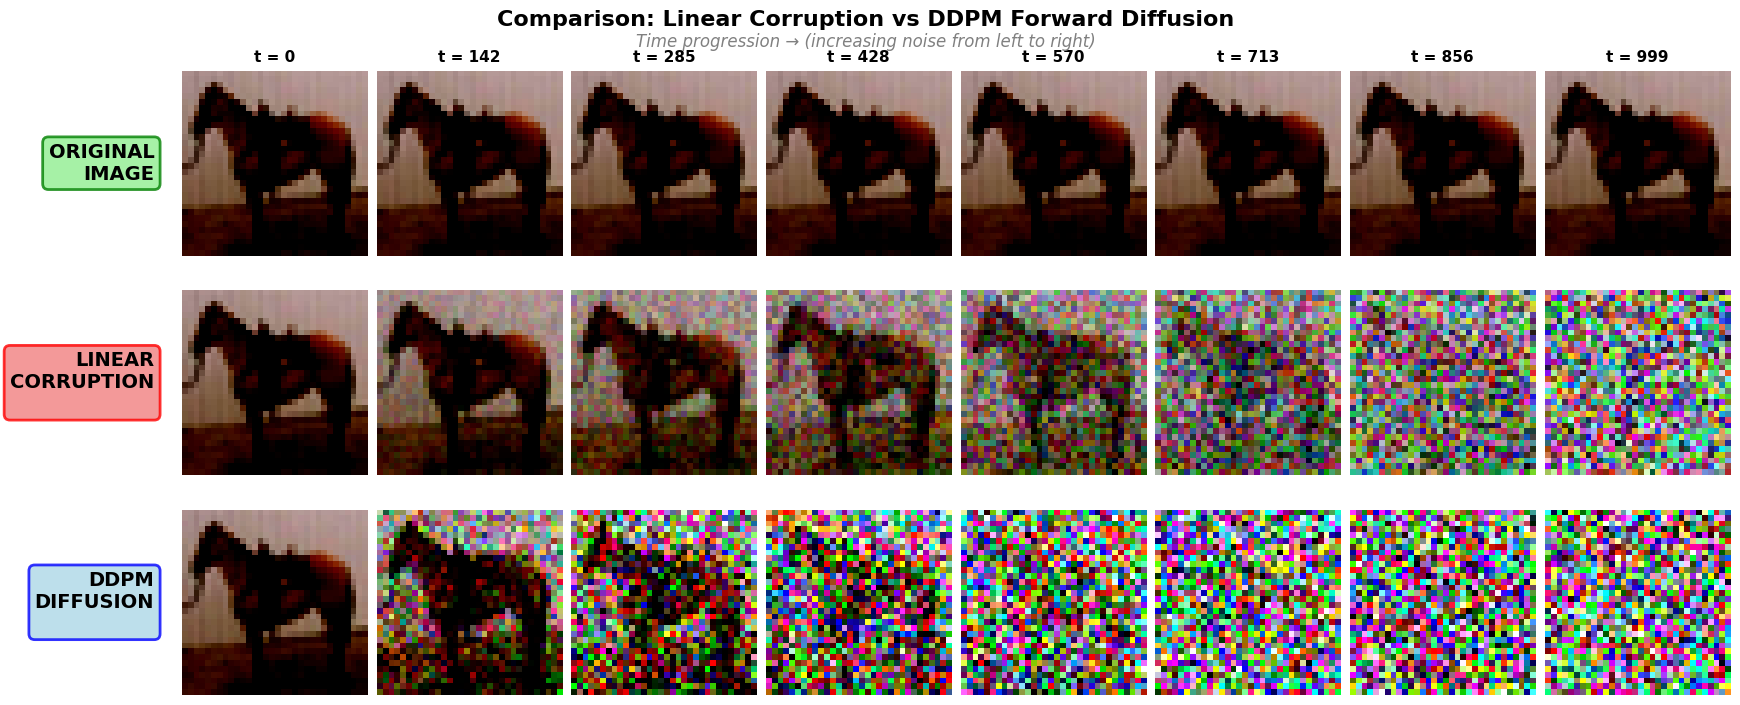

In [ ]:
batch_x, batch_y = next(iter(train_dataloader))
print(f"Batch shape: {batch_x.shape}")

x = batch_x[0:1]

print("\n[2] Creating side-by-side comparison...")
fig1 = compare_corruption_methods(x, num_steps=8)
plt.show()



### Key takeaways
This illustrates why scheduled noise is crucial: It ensures the reverse process (denoising) is tractable, unlike uniform mixing. Run the code to see noise build left-to-right, expect DDPM row to retain faint outlines at high t, unlike the red row's chaos.

# part 3. U-Net Architecture

Build  U-Net architecture that serves as the noise prediction backbone of your diffusion model. This network must learn to predict the noise component in images across all noise levels and (optionally) all object classes.

The denoising model needs to know how noisy the input image is.

At t=0 (clean image) → apply light denoising

At t=500 (medium noise) → apply moderate denoising

At t=999 (pure noise) → apply heavy denoising

Convert the timestep integer (0-999) into a rich vector representation that the  network can understand.


Why Sinusoidal?

 Fixed function - no parameters to learn

 Smooth - nearby timesteps (t=500, t=501) have similar embeddings

 Rich - uses multiple frequencies to capture patterns at different scales

 Proven - same technique used in Transformers



In [ ]:
class SinusoidalPositionEmbeddings(nn.Module):
    """Sinusoidal positional embeddings for timesteps"""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings



#Need to fill

Implement a residual-style block that conditions on a timestep

ResidualBlock combines two convolution blocks with skip connections and time embedding injection, allowing deep networks to learn denoising at different noise levels while maintaining stable gradient flow.

In [ ]:
class ResidualBlock(nn.Module):
    """Basic residual block with time embedding
     Tips:
    - you may follow this general structure: Norm → Activation → Conv → (add time) → Norm → Activation → Dropout → Conv → Residual Add.
    - Keep spatial size constant by using padding=1 in 3×3 convs.
    - Use SiLU (same as Swish) for activation.
    - GroupNorm is more stable than BatchNorm for small batches.
    """
    def __init__(self, in_channels, out_channels, time_emb_dim, dropout=0.0):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels

        # First normalization + conv
        self.norm1 = nn.GroupNorm(num_groups=8, num_channels=in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        # Time embedding projection (time_emb_dim -> out_channels)
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_channels)
        )

        # Second normalization + conv
        self.norm2 = nn.GroupNorm(num_groups=8, num_channels=out_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        # Skip connection: if channel dims change, use 1x1 conv
        if in_channels != out_channels:
            self.skip_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.skip_conv = nn.Identity()

    def forward(self, x, time_emb):
    # First half: Norm -> SiLU -> Conv
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        # Add time embedding (broadcast over H and W)
        # time_emb: (B, time_emb_dim) -> (B, out_channels, 1, 1)
        t = self.time_mlp(time_emb)
        h = h + t[:, :, None, None]
        # Second half: Norm -> SiLU -> Dropout -> Conv
        h = self.norm2(h)
        h = F.silu(h)
        h = self.dropout(h)
        h = self.conv2(h)

        # Residual add
        return h + self.skip_conv(x)

#Need to fill



Convolutional layers only look at local neighborhoods ( 3×3 pixels). They can't directly relate distant parts of an image.


Self-attention allows every pixel to look at every other pixel, capturing long-range dependencies. In Diffusion Models, Attention helps maintain global coherence ensures generated images have consistent structure and appearance throughout.

In [ ]:
class AttentionBlock(nn.Module):
    """Self-attention block for global context."""
    def __init__(self, channels, num_heads=1):
        super().__init__()
        self.channels = channels
        self.num_heads = num_heads

        # Normalize features before attention
        self.norm = nn.GroupNorm(num_groups=8, num_channels=channels)

        # Produce Q, K, V using 1×1 conv
        self.qkv = nn.Conv2d(channels, channels * 3, kernel_size=1)

        # Final projection after attention
        self.proj_out = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x):
        b, c, h, w = x.shape
        h_in = self.norm(x)

        # Compute Q, K, V
        qkv = self.qkv(h_in)
        q, k, v = qkv.chunk(3, dim=1)

        # Flatten spatial dims → sequence of tokens
        q = q.reshape(b, c, h * w)
        k = k.reshape(b, c, h * w)
        v = v.reshape(b, c, h * w)

        # Multi-head (optional)
        if self.num_heads > 1:
            head_dim = c // self.num_heads
            q = q.view(b, self.num_heads, head_dim, h * w)
            k = k.view(b, self.num_heads, head_dim, h * w)
            v = v.view(b, self.num_heads, head_dim, h * w)

            # Scaled dot-product attention
            attn = torch.einsum('bnhd,bnhD->bnhdD', q, k) / (head_dim ** 0.5)
            attn = F.softmax(attn, dim=-1)

            # Weighted average of values
            out = torch.einsum('bnhdD,bnhD->bnhd', attn, v)
            out = out.reshape(b, c, h * w)

        else:
            # Single-head attention
            attn = torch.bmm(q.transpose(1, 2), k) / (c ** 0.5)  # (B, N, N)
            attn = F.softmax(attn, dim=-1)

            out = torch.bmm(attn, v.transpose(1, 2))             # (B, N, C)
            out = out.transpose(1, 2)                            # (B, C, N)

        # Reshape back to image shape
        out = out.reshape(b, c, h, w)

        # Final projection + residual connection
        out = self.proj_out(out)
        return x + out


In [ ]:
class Downsample(nn.Module):
    """Downsample block"""
    """Reduces spatial resolution by 2× (i.e., 32×32 → 16×16) using strided convolution
    to compress features as we go deeper in the U-Net encoder."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Stride-2 conv halves H and W
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)

In [ ]:
class Upsample(nn.Module):
    """Upsample block"""
    """Increases spatial resolution by 2× (i.e.,16×16 → 32×32) using interpolation + convolution
    to expand features as we go up in the U-Net decoder."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # After interpolation, refine features with a conv
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x):
        # Bilinear resize (H,W → 2H, 2W)
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        return self.conv(x)


#Gather together (Need to Fill)




**Goal:** Build a diffusion U-Net that takes an image, a timestep, and optionally a class label, then predicts noise.

**Input and output**
The model takes:

* `x`: an image tensor
* `t`: a tensor of timesteps
* `y`: optional class labels


---

**Time and class embeddings**

1. Convert each timestep into a sinusoidal embedding.
2. Pass it through two Linear layers with a SiLU activation in between to form the final time embedding.
3. If the model is conditional, look up a class embedding and add it to the time embedding.

---

**Residual block**
Each block has two 3×3 convolution layers.

* Normalize, activate, and convolve.
* Add the projected time embedding to the feature map.
* Normalize, activate, apply dropout, and convolve again.
* Add a shortcut connection (either identity or 1×1 convolution if channels differ).

---

**Attention block**
Applies self-attention over the spatial positions.

* Compute query, key, and value from the feature map using a 1×1 convolution.
* Split into multiple heads and perform scaled dot-product attention.
* Project back and add the result to the original feature map.

---

**U-Net structure**


1. **Encoder:** several stages of residual blocks, followed by downsampling. Save outputs for skip connections.
2. **Middle:** a residual block, an attention block, and another residual block.
3. **Decoder:** concatenate skip features, apply residual blocks, then upsample.


---




In [ ]:
class UNet(nn.Module):
    """U-Net architecture for diffusion models: predicts noise from (x, t, [y])."""
    def __init__(
        self,
        in_channels=3,
        out_channels=3,
        base_channels=128,
        channel_mult=(1, 2, 2, 2),
        num_res_blocks=2,
        time_emb_dim=512,
        num_classes=None,
        dropout=0.1,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.num_classes = num_classes


        # Time (and optional class) embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim),
        )

        if num_classes is not None:
            self.class_emb = nn.Embedding(num_classes, time_emb_dim)
        else:
            self.class_emb = None


        # Input conv
        self.init_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)


        # Encoder (downsampling path)
        self.down_blocks = nn.ModuleList()
        self.downsamples = nn.ModuleList()
        self.skip_channels = []  # track channels for skip connections

        curr_channels = base_channels
        channels_per_level = [base_channels * m for m in channel_mult]

        for level, ch in enumerate(channels_per_level):
            for _ in range(num_res_blocks):
                block = ResidualBlock(curr_channels, ch, time_emb_dim, dropout=dropout)
                self.down_blocks.append(block)
                curr_channels = ch
                self.skip_channels.append(ch)

            if level != len(channels_per_level) - 1:
                self.downsamples.append(Downsample(curr_channels, curr_channels))
            else:
                self.downsamples.append(nn.Identity())


        # Middle (bottleneck)
        self.mid_block1 = ResidualBlock(curr_channels, curr_channels, time_emb_dim, dropout=dropout)
        self.mid_attn = AttentionBlock(curr_channels)
        self.mid_block2 = ResidualBlock(curr_channels, curr_channels, time_emb_dim, dropout=dropout)


        # Decoder (upsampling path)
        self.up_blocks = nn.ModuleList()
        self.upsamples = nn.ModuleList()

        rev_channels = list(reversed(channels_per_level))
        rev_skip_channels = list(reversed(self.skip_channels))

        skip_idx = 0
        for level, ch in enumerate(rev_channels):
            for _ in range(num_res_blocks):
                skip_ch = rev_skip_channels[skip_idx]
                skip_idx += 1

                # concat current + skip along channel dim
                in_ch = curr_channels + skip_ch
                block = ResidualBlock(in_ch, ch, time_emb_dim, dropout=dropout)
                self.up_blocks.append(block)
                curr_channels = ch

            if level != len(rev_channels) - 1:
                self.upsamples.append(Upsample(curr_channels, curr_channels))
            else:
                self.upsamples.append(nn.Identity())


        # Output conv
        self.final_conv = nn.Sequential(
            nn.GroupNorm(num_groups=8, num_channels=curr_channels),
            nn.SiLU(),
            nn.Conv2d(curr_channels, out_channels, kernel_size=3, padding=1),
        )

    def forward(self, x, time, y=None):
        """
        x:    (B, C, H, W) input image (noisy)
        time: (B,) timesteps
        y:    (B,) class labels (optional, if conditional)
        """
        # Time embedding (and optional class conditioning)
        t_emb = self.time_mlp(time)
        if self.class_emb is not None and y is not None:
            t_emb = t_emb + self.class_emb(y)

        # Initial conv
        h = self.init_conv(x)
        skips = []

        # Encoder
        down_block_idx = 0
        for level in range(len(self.downsamples)):
            for _ in range(len(self.skip_channels) // len(self.downsamples) // 1):
                h = self.down_blocks[down_block_idx](h, t_emb)
                skips.append(h)
                down_block_idx += 1
            # downsample after this level
            h = self.downsamples[level](h)

        # Middle
        h = self.mid_block1(h, t_emb)
        h = self.mid_attn(h)
        h = self.mid_block2(h, t_emb)

        # Decoder
        up_block_idx = 0
        for level in range(len(self.upsamples)):
            for _ in range(len(self.skip_channels) // len(self.upsamples) // 1):  # num_res_blocks
                skip = skips.pop()
                h = torch.cat([h, skip], dim=1)
                h = self.up_blocks[up_block_idx](h, t_emb)
                up_block_idx += 1
            # upsample after this level
            h = self.upsamples[level](h)

        # Output
        return self.final_conv(h)


# PART 4: DIFFUSION PROCESS

linear_beta_schedule: Returns betas that increase linearly from beta_start to beta_end across timesteps.

cosine_beta_schedule: Returns betas from a cosine cumulative alpha schedule for a smoother noise ramp that often samples better.

In [ ]:
def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    """Linear schedule for beta values"""
    return torch.linspace(beta_start, beta_end, timesteps)


def cosine_beta_schedule(timesteps, s=0.008):
    """Cosine schedule for beta values (often works better)"""
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

#Need to Fill


We need a mathematical framework to:

Forward Process: Gradually add noise to images (training data generation)
Reverse Process: Gradually remove noise from pure noise (image generation)
Training: Teach the model to predict and remove noise at any timestep.



GaussianDiffusion implements the DDPM (Denoising Diffusion Probabilistic Models) algorithm that defines:

How much noise to add at each timestep (noise schedule)
How to sample noisy images at any timestep t (forward diffusion)
How to denoise step-by-step (reverse diffusion)
Loss function for training the model


---


DDIM sampling is a **faster, deterministic version** of the standard DDPM sampling process.

- It reuses the same trained diffusion model but **skips multiple timesteps** using a fixed stride schedule.  
- Each step directly computes \( x_{t-1} \) from \( x_t \) and the model’s predicted noise, **avoiding random sampling** unless a noise factor (`eta > 0`) is added.  
- When `eta = 0`, the process becomes **deterministic** (same output every time).  
- This allows generation in **far fewer steps** (i.e., 50 instead of 1000) while maintaining similar image quality.

---


In [ ]:
class GaussianDiffusion:
    """Gaussian Diffusion Process for DDPM"""
    def __init__(self, timesteps=1000, beta_schedule='linear'):
        self.timesteps = timesteps

        # Define beta schedule
        if beta_schedule == 'linear':
            betas = linear_beta_schedule(timesteps)
        elif beta_schedule == 'cosine':
            betas = cosine_beta_schedule(timesteps)
        else:
            raise ValueError(f"Unknown beta schedule: {beta_schedule}")

        # Pre-calculate useful values
        self.betas = betas
        self.alphas = 1.0 - betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

        # q(x_t | x_0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

        # q(x_{t-1} | x_t, x_0)
        self.posterior_variance = (
            betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )
        self.posterior_log_variance_clipped = torch.log(
            torch.clamp(self.posterior_variance, min=1e-20)
        )
        self.posterior_mean_coef1 = (
            betas * torch.sqrt(self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )
        self.posterior_mean_coef2 = (
            (1.0 - self.alphas_cumprod_prev) * torch.sqrt(self.alphas)
            / (1.0 - self.alphas_cumprod)
        )

    def extract(self, a, t, x_shape):
        """Extract values at indices t and reshape to broadcast over x."""
        a = a.to(t.device)
        b = t.shape[0]
        out = a.gather(0, t)          # (B,)
        return out.reshape(b, *((1,) * (len(x_shape) - 1)))

    def q_sample(self, x_start, t, noise=None):
        """Forward diffusion: sample x_t from q(x_t | x_0)."""
        if noise is None:
            noise = torch.randn_like(x_start)

        sqrt_alphabar_t = self.extract(self.sqrt_alphas_cumprod, t, x_start.shape)
        sqrt_one_minus_alphabar_t = self.extract(
            self.sqrt_one_minus_alphas_cumprod, t, x_start.shape
        )
        return sqrt_alphabar_t * x_start + sqrt_one_minus_alphabar_t * noise

    def predict_start_from_noise(self, x_t, t, noise):
        """Compute x_0 from x_t and predicted noise ε."""
        sqrt_alphabar_t = self.extract(self.sqrt_alphas_cumprod, t, x_t.shape)
        sqrt_one_minus_alphabar_t = self.extract(
            self.sqrt_one_minus_alphas_cumprod, t, x_t.shape
        )
        return (x_t - sqrt_one_minus_alphabar_t * noise) / sqrt_alphabar_t

    def q_posterior(self, x_start, x_t, t):
        """Posterior q(x_{t-1} | x_t, x_0) mean and variance."""
        coef1 = self.extract(self.posterior_mean_coef1, t, x_t.shape)
        coef2 = self.extract(self.posterior_mean_coef2, t, x_t.shape)
        mean = coef1 * x_start + coef2 * x_t
        var = self.extract(self.posterior_variance, t, x_t.shape)
        log_var = self.extract(self.posterior_log_variance_clipped, t, x_t.shape)
        return mean, var, log_var

    def p_mean_variance(self, model, x_t, t, y=None, clip_denoised=True):
        """Model p(x_{t-1} | x_t): predict noise → x_0 → posterior."""
        # model predicts ε_\theta
        eps_pred = model(x_t, t, y)
        x0_pred = self.predict_start_from_noise(x_t, t, eps_pred)
        if clip_denoised:
            x0_pred = x0_pred.clamp(-1.0, 1.0)

        mean, var, log_var = self.q_posterior(x0_pred, x_t, t)
        return mean, var, log_var

    @torch.no_grad()
    def p_sample(self, model, x_t, t, y=None):
        """Sample x_{t-1} from p(x_{t-1} | x_t)."""
        b = x_t.shape[0]
        mean, var, log_var = self.p_mean_variance(model, x_t, t, y)
        # add noise except for t == 0
        noise = torch.randn_like(x_t)
        nonzero_mask = (t != 0).float().view(b, *([1] * (x_t.dim() - 1)))
        return mean + nonzero_mask * torch.sqrt(var) * noise

    @torch.no_grad()
    def p_sample_loop(self, model, shape, y=None):
        """DDPM sampling: start from noise and iterate all timesteps."""
        device = next(model.parameters()).device
        b = shape[0]
        x = torch.randn(shape, device=device)

        for i in reversed(range(self.timesteps)):
            t = torch.full((b,), i, device=device, dtype=torch.long)
            x = self.p_sample(model, x, t, y)

        return x

    @torch.no_grad()
    def ddim_sample(self, model, shape, y=None, ddim_timesteps=50, eta=0.0):
        """
        DDIM sampling: fewer, deterministic-ish steps using a subset of timesteps.
        """
        device = next(model.parameters()).device
        b = shape[0]
        x = torch.randn(shape, device=device)

        # choose a subset of timesteps (e.g., 50 out of 1000)
        step_indices = torch.linspace(
            0, self.timesteps - 1, steps=ddim_timesteps, dtype=torch.long, device=device
        )
        step_indices = step_indices.flip(0)  # go from T-1 → 0

        alphas_cumprod = self.alphas_cumprod.to(device)

        for i, t_int in enumerate(step_indices):
            t = torch.full((b,), t_int, device=device, dtype=torch.long)

            eps_pred = model(x, t, y)

            alphabar_t = self.extract(alphas_cumprod, t, x.shape)
            x0_pred = self.predict_start_from_noise(x, t, eps_pred).clamp(-1.0, 1.0)

            if i == ddim_timesteps - 1:
                # last step: return x_0
                x = x0_pred
                break

            t_prev_int = step_indices[i + 1]
            t_prev = torch.full((b,), t_prev_int, device=device, dtype=torch.long)
            alphabar_prev = self.extract(alphas_cumprod, t_prev, x.shape)

            # DDIM update
            sigma_t = (
                eta
                * torch.sqrt(
                    (1 - alphabar_prev) / (1 - alphabar_t)
                    * (1 - alphabar_t / alphabar_prev)
                )
            )
            # direction preserving term
            dir_xt = torch.sqrt(torch.clamp(1 - alphabar_prev - sigma_t**2, min=0.0)) * eps_pred

            x = torch.sqrt(alphabar_prev) * x0_pred + dir_xt

            if eta > 0.0:
                x = x + sigma_t * torch.randn_like(x)

        return x

    def training_losses(self, model, x_start, t, y=None):
        """
        Simple DDPM loss: MSE between true noise and predicted noise.
        """
        noise = torch.randn_like(x_start)
        x_t = self.q_sample(x_start, t, noise)
        noise_pred = model(x_t, t, y)
        return F.mse_loss(noise_pred, noise)


# PART 5: TRAINING FUNCTIONS (Need to Fill)


whilr training, sample couple of images per epoch. This helps to visualize how the noise is getting shaped!!!

In [ ]:
def train_unconditional(model, diffusion, train_loader, test_loader, num_epochs=50, lr=2e-4,
                       save_dir='./checkpoints'):
    """Train unconditional diffusion model"""
    """
    Unconditional DDPM training:
    - For each batch: pick random t, compute diffusion MSE loss, step optimizer.
    - Validate with the same loss on random t.
    - Periodically sample images with DDIM and save a checkpoint.
    """
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(os.path.join(save_dir, "samples"), exist_ok=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    losses = []
    val_losses = []

    for epoch in range(1, num_epochs + 1):
        # TRAIN
        model.train()
        epoch_losses = []

        for x, _ in train_loader:
            x = x.to(device)  # assume already in [-1, 1]
            b = x.size(0)
            t = torch.randint(0, diffusion.timesteps, (b,), device=device).long()

            loss = diffusion.training_losses(model, x, t)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        mean_train_loss = float(np.mean(epoch_losses))
        losses.append(mean_train_loss)

        # VAL
        model.eval()
        val_epoch_losses = []
        with torch.no_grad():
            for x_val, _ in test_loader:
                x_val = x_val.to(device)
                b_val = x_val.size(0)
                t_val = torch.randint(0, diffusion.timesteps, (b_val,), device=device).long()

                val_loss = diffusion.training_losses(model, x_val, t_val)
                val_epoch_losses.append(val_loss.item())

        mean_val_loss = float(np.mean(val_epoch_losses))
        val_losses.append(mean_val_loss)

        print(f"[Epoch {epoch}/{num_epochs}] "
              f"train_loss={mean_train_loss:.4f}  val_loss={mean_val_loss:.4f}")

        # SAMPLE SOME IMAGES EACH EPOCH
        with torch.no_grad():
            sample_shape = (16, model.in_channels, 32, 32)  # 16 CIFAR-10 images
            samples = diffusion.ddim_sample(
                model,
                shape=sample_shape,
                y=None,
                ddim_timesteps=50,
                eta=0.0
            )
            samples = (samples + 1) / 2  # [-1,1] -> [0,1]
            samples = torch.clamp(samples, 0.0, 1.0)

            grid = vutils.make_grid(samples, nrow=4)
            sample_path = os.path.join(save_dir, "samples", f"samples_epoch_{epoch:03d}.png")
            vutils.save_image(grid, sample_path)

        # SAVE CHECKPOINT
        ckpt_path = os.path.join(save_dir, f"model_epoch_{epoch:03d}.pt")
        torch.save(model.state_dict(), ckpt_path)
    return losses, val_losse


#### Same as unconditional, but drop labels with prob p_uncond so the model learns both conditional and unconditional modes for CFG at sampling.

In [ ]:
def train_conditional(model, diffusion, train_loader, test_loader, num_epochs=50, lr=2e-4,
                     p_uncond=0.1, save_dir='./checkpoints_conditional'):
    """
    Train conditional diffusion model with classifier-free guidance.
    Args:
        p_uncond: Probability of dropping class labels (for classifier-free guidance)
    """
    """
    Train conditional diffusion with classifier-free guidance (CFG).
    - Randomly replace labels with UNCOND_ID with prob p_uncond.
    - Optimize MSE on predicted noise.
    - Periodically sample per-class with CFG.

    """
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(os.path.join(save_dir, "samples"), exist_ok=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    losses = []
    val_losses = []

    for epoch in range(1, num_epochs + 1):
        # --------- TRAIN ---------
        model.train()
        epoch_losses = []

        for x, y in train_loader:
            x = x.to(device)               # expected in [-1, 1]
            y = y.to(device).long()        # class labels

            b = x.size(0)
            t = torch.randint(0, diffusion.timesteps, (b,), device=device).long()

            # drop labels with probability p_uncond (classifier-free guidance)
            if p_uncond > 0.0:
                drop_mask = (torch.rand_like(y.float()) < p_uncond)
                y = y.clone()
                y[drop_mask] = UNCOND_ID   # UNCOND_ID must be defined elsewhere

            loss = diffusion.training_losses(model, x_start=x, t=t, y=y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        mean_train_loss = float(np.mean(epoch_losses))
        losses.append(mean_train_loss)

        # --------- VAL ---------
        model.eval()
        val_epoch_losses = []
        with torch.no_grad():
            for x_val, y_val in test_loader:
                x_val = x_val.to(device)
                y_val = y_val.to(device).long()

                b_val = x_val.size(0)
                t_val = torch.randint(0, diffusion.timesteps, (b_val,), device=device).long()

                # Use same label-drop scheme in val for consistency
                if p_uncond > 0.0:
                    drop_mask_val = (torch.rand_like(y_val.float()) < p_uncond)
                    y_val = y_val.clone()
                    y_val[drop_mask_val] = UNCOND_ID

                val_loss = diffusion.training_losses(model, x_start=x_val, t=t_val, y=y_val)
                val_epoch_losses.append(val_loss.item())

        mean_val_loss = float(np.mean(val_epoch_losses))
        val_losses.append(mean_val_loss)

        print(f"[Epoch {epoch}/{num_epochs}] "
              f"train_loss={mean_train_loss:.4f}  val_loss={mean_val_loss:.4f}")

        # --------- PER-CLASS SAMPLING (conditional) ---------
        with torch.no_grad():
            # assume model.num_classes is defined and UNCOND_ID is reserved for 'no label'
            n_classes = getattr(model, "num_classes", 10)
            num_per_class = 4
            all_labels = []

            for cls in range(n_classes):
                all_labels.append(torch.full((num_per_class,), cls, device=device, dtype=torch.long))
            y_samples = torch.cat(all_labels, dim=0)

            sample_shape = (len(y_samples), model.in_channels, 32, 32)
            samples = diffusion.ddim_sample(
                model,
                shape=sample_shape,
                y=y_samples,
                ddim_timesteps=50,
                eta=0.0,
            )
            samples = (samples + 1) / 2.0
            samples = torch.clamp(samples, 0.0, 1.0)

            grid = vutils.make_grid(samples, nrow=num_per_class)
            sample_path = os.path.join(save_dir, "samples", f"samples_epoch_{epoch:03d}.png")
            vutils.save_image(grid, sample_path)

        # --------- SAVE CHECKPOINT ---------
        ckpt_path = os.path.join(save_dir, f"model_epoch_{epoch:03d}.pt")
        torch.save(model.state_dict(), ckpt_path)
    return losses, val_losses

#PART 6: CLASSIFIER-FREE GUIDANCE SAMPLING


Generates images using Classifier-Free Guidance (CFG), which strengthens class conditioning by blending conditional and unconditional predictions to produce higher-quality, class-specific images in just 50 steps instead of 1000

In [ ]:
def sample_with_cfg(model, diffusion, shape, y, guidance_scale=3.0, ddim_timesteps=50):
    """
    Sample with Classifier-Free Guidance.

    Args:
        guidance_scale: Higher values = stronger conditioning (typical range: 1-10)
    """
    device = next(model.parameters()).device
    batch_size = shape[0]

    # Create DDIM timestep schedule
    c = diffusion.timesteps // ddim_timesteps
    ddim_timestep_seq = np.asarray(list(range(0, diffusion.timesteps, c)))
    ddim_timestep_seq = ddim_timestep_seq + 1
    ddim_timestep_prev_seq = np.append(np.array([0]), ddim_timestep_seq[:-1])

    # Start from pure noise
    img = torch.randn(shape, device=device)

    # Unconditional class index
    y_uncond = torch.full_like(y, 10)  # 10 = unconditional

    for i in tqdm(reversed(range(0, ddim_timesteps)), desc='CFG Sampling', total=ddim_timesteps):
        t = torch.full((batch_size,), ddim_timestep_seq[i], device=device, dtype=torch.long)
        t_prev = torch.full((batch_size,), ddim_timestep_prev_seq[i], device=device, dtype=torch.long)

        # Predict noise with and without conditioning
        pred_noise_cond = model(img, t, y)
        pred_noise_uncond = model(img, t, y_uncond)

        # Apply classifier-free guidance
        pred_noise = pred_noise_uncond + guidance_scale * (pred_noise_cond - pred_noise_uncond)

        # Predict x_0
        alpha_cumprod_t = diffusion.extract(diffusion.alphas_cumprod, t, img.shape)
        alpha_cumprod_t_prev = diffusion.extract(diffusion.alphas_cumprod, t_prev, img.shape)

        pred_x0 = (img - torch.sqrt(1 - alpha_cumprod_t) * pred_noise) / torch.sqrt(alpha_cumprod_t)
        pred_x0 = torch.clamp(pred_x0, -1.0, 1.0)

        # Compute direction pointing to x_t
        dir_xt = torch.sqrt(1 - alpha_cumprod_t_prev) * pred_noise

        # Compute x_{t-1}
        img = torch.sqrt(alpha_cumprod_t_prev) * pred_x0 + dir_xt

    return img

#Main execution

> **Note:**  
> The default setting uses a **linear noise schedule**, but you’re encouraged to experiment with a **cosine schedule** as well for potentially smoother results.

---

###  Observability Check
Sampling images **after each epoch** helps visualize training progress.  
In the **initial epochs**, the outputs may appear incoherent, but as training continues, the images **gradually become clearer**.  
If time allows, try **increasing the number of epochs** to observe a more complete denoising progression.


In [ ]:
print("\n" + "=" * 80)
print("TRAINING UNCONDITIONAL MODEL")
print("=" * 80)

# Initialize unconditional model
print("\n[2] Initializing unconditional model...")
unconditional_model = UNet(
        in_channels=3,
        out_channels=3,
        base_channels=128,
        channel_mult=(1, 2, 2, 2),
        num_res_blocks=2,
        num_classes=None
).to(device)

num_params = sum(p.numel() for p in unconditional_model.parameters())
print(f"Model Parameters: {num_params / 1e6:.1f}M")

# Create diffusion instance
diffusion_unconditional = GaussianDiffusion(timesteps=1000, beta_schedule='linear')

# Train unconditional model
print("\n[3] Training unconditional model...")

unconditional_losses, val_unconditional_losses = train_unconditional(
        unconditional_model,
        diffusion_unconditional,
        train_dataloader,
        test_dataloader,
        num_epochs=5,        # <<< was 100, reduce for time
        lr=2e-4
    )

# Plot training loss
plot_training_losses(unconditional_losses, val_unconditional_losses)

# Generate samples
print("\n[4] Generating unconditional samples...")
unconditional_model.eval()
with torch.no_grad():
    samples = diffusion_unconditional.ddim_sample(
        unconditional_model,
        (8, 3, 32, 32),      # <<< was (16, 3, 32, 32) – fewer images
        ddim_timesteps=20    # <<< was 50 – fewer DDIM steps
    )
    show_images(samples, nrow=4, save_path='./unconditional_samples.png')


print("\n" + "=" * 80)
print("TRAINING CONDITIONAL MODEL")
print("=" * 80)

# Initialize conditional model
print("\n[5] Initializing conditional model...")
conditional_model = UNet(
        in_channels=3,
        out_channels=3,
        base_channels=128,
        channel_mult=(1, 2, 2, 2),
        num_res_blocks=2,
        num_classes=10  # CIFAR-10 has 10 classes
).to(device)

num_params = sum(p.numel() for p in conditional_model.parameters())
print(f"Model Parameters: {num_params / 1e6:.1f}M")

# Create diffusion instance
diffusion_conditional = GaussianDiffusion(timesteps=1000, beta_schedule='linear')

# Train conditional model
print("\n[6] Training conditional model...")

conditional_losses, val_conditional_losses = train_conditional(
        conditional_model,
        diffusion_conditional,
        train_dataloader,
        test_dataloader,
        num_epochs=5,        # <<< was 100, reduce for time
        lr=2e-4,
        p_uncond=0.1
    )

# Plot training loss
plot_training_losses(conditional_losses, val_conditional_losses)

# Generate conditional samples
print("\n[7] Generating conditional samples...")
conditional_model.eval()

# Sample with different guidance scales
for guidance_scale in [3.0]:   # <<< just one scale for speed (was [1.0, 3.0, 7.0])
    print(f"\nGuidance Scale: {guidance_scale}")
    y_sample = torch.arange(10, device=device).repeat(1)[:8]   # <<< 8 samples instead of 16

    with torch.no_grad():   # <<< moved inside the loop so it uses each guidance_scale
        samples = sample_with_cfg(
            conditional_model,
            diffusion_conditional,
            (8, 3, 32, 32),     # <<< fewer images
            y_sample,
            guidance_scale=guidance_scale,
            ddim_timesteps=20   # <<< fewer DDIM steps
        )

    show_images(samples, y_sample, nrow=4)


TRAINING UNCONDITIONAL MODEL

[2] Initializing unconditional model...
Model Parameters: 29.9M

[3] Training unconditional model...


In [ ]:
print("\n[8] Creating visualizations...")

sample_img, _ = next(iter(test_dataloader))
sample_img = sample_img[:1].to(device)
visualize_forward_diffusion(sample_img, diffusion_unconditional)

# Visualize reverse diffusion
unconditional_model.eval()
visualize_reverse_diffusion(
    unconditional_model,
    diffusion_unconditional,
    (1, 3, 32, 32)
)

print("\n" + "=" * 80)
print("TRAINING COMPLETE!")
print("=" * 80)